## Test of Normality
***It has been criticized that equity returns don't follow a normal distribution. They generally have excess kurtosis. They are "Fat tailed" as in extreme events occur more frequently than they would if they were normally distributed. Conversely extreme events are "Thin tailed" in normal distribution***

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
pd.options.display.float_format = '{:.2f}'.format

In [8]:
stock = pd.read_csv("../../../data/TSLA.5MIN.csv")
stock['returns'] = stock.close.pct_change()

## Frequency distribution of returns and normally sampled data based on returns' mean and variance.
- One that looks like normally distributed
- The other one is actually normally distributed

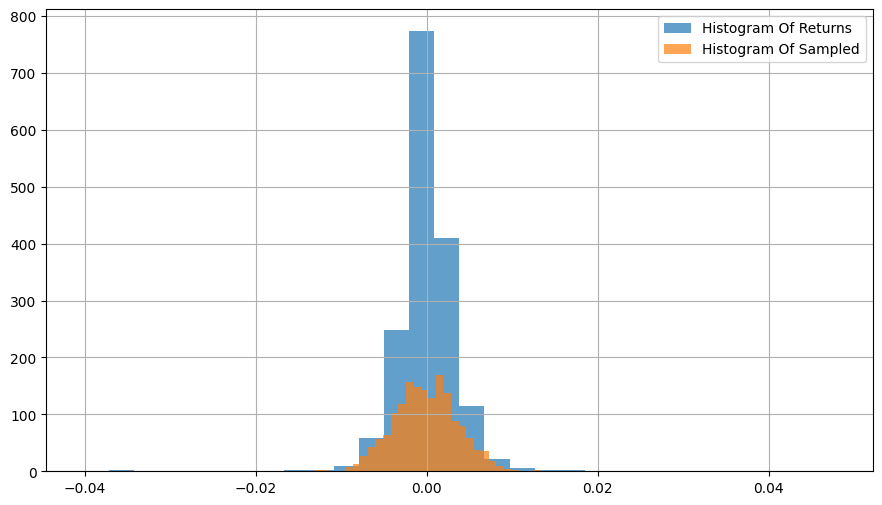

In [13]:
sample_data = np.random.normal(loc = stock['returns'].mean(), scale=stock['returns'].std(), size = stock['returns'].shape[0])
plt.style.use('default')
fig, hist_ax = plt.subplots(figsize=(6*1.7777, 6))
hist_ax.hist(stock['returns'], bins=30, histtype='bar', alpha=0.7, label="Histogram Of Returns")
hist_ax.hist(sample_data, bins=30,      histtype='bar', alpha=0.7, label="Histogram Of Sampled")
hist_ax.legend()
hist_ax.grid(True)

## JARQUE BERA
##### Only works for a large enough number of data samples (>2000) as the test statistic asymptotically has a Chi-squared distribution with 2 degrees of freedom

## ANDERSON DARLING TEST
- **Null hypothesis = Random sample was drawn from a normal distribution (with unspecified mean and standard deviation)**
- **Null hypothesis = OR Data is normally distributed**
- **Higher the test statistics more likely to reject that data is normally distributed.**
- **Lower the test statistics can not reject the null hypothesis**

In [14]:
from scipy.stats import anderson

In [15]:
return_res = anderson(stock['returns'].dropna())
sample_res = anderson(sample_data)

/tmp/ipykernel_14400/141807603.py:1: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  return_res = anderson(stock['returns'].dropna())
/tmp/ipykernel_14400/141807603.py:2: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to ap

In [18]:
print(f"- Returns. Statistics {return_res.statistic}")
print(f"- Sample. Statistics {sample_res.statistic}")
print("*" * 50)
temp = pd.DataFrame( {"Ret.Cri.Val":  return_res.critical_values, 
               "Sam.Cri.Val" : sample_res.critical_values,
               "Ret.Sig":return_res.significance_level,
               "Sam.Sig":sample_res.significance_level})
print(temp)
print("*" * 50)
print("- Returns test statistics rejects null hypothesis hard at the 1% significance. Meaning NOT normally distributed")
print("- Sample test statistics can not reject null hypothesis even at 50% significance. Meaning NORMALY Distributed")

- Returns. Statistics 45.316099587172175
- Sample. Statistics 0.30589814414861394
**************************************************
   Ret.Cri.Val  Sam.Cri.Val  Ret.Sig  Sam.Sig
0         0.56         0.56    15.00    15.00
1         0.63         0.63    10.00    10.00
2         0.75         0.75     5.00     5.00
3         0.87         0.87     2.50     2.50
4         1.03         1.03     1.00     1.00
**************************************************
- Returns test statistics rejects null hypothesis hard at the 1% significance. Meaning NOT normally distributed
- Sample test statistics can not reject null hypothesis even at 50% significance. Meaning NORMALY Distributed


## SHAPIRO TEST
- **Null hypothesis = Random sample was drawn from a normal distribution (with unspecified mean and standard deviation)**
- **Null hypothesis = OR Data is normally distributed**
- **A p-value less than 0.05 rejects the null hypothesis, meaning there is a low probability of data being normally distributed**
- **A p-value greater than 0.05 fails to reject the null hypothesis, meaning the data likely normally distributed**

In [19]:
from scipy.stats import shapiro

In [20]:
return_res = shapiro(stock['returns'].dropna())
sample_res = shapiro(sample_data)
pd.DataFrame([[return_res.pvalue, return_res.statistic], [sample_res.pvalue, sample_res.statistic]], 
             columns = ['P.Val','Statistics'], index = ['Returns','Sample.Data'])

,P.Val,Statistics
Returns,0.00,0.78
Sample.Data,0.51,1.00


## NORMALITY SKEWNESS AND KURTOSIS TEST
- **Null hypothesis = Random sample was drawn from a normal distribution (with unspecified mean and standard deviation)**
- **Null hypothesis = OR Data is normally distributed**
- **A p-value less than 0.05 rejects the null hypothesis, meaning there is a low probability of data being normally distributed**
- **A p-value greater than 0.05 fails to reject the null hypothesis, meaning the data is likely normally distributed**

In [21]:
from scipy.stats import normaltest

In [22]:
return_res = normaltest(stock['returns'].dropna())
sample_res = normaltest(sample_data)
pd.DataFrame([[return_res.pvalue, return_res.statistic], [sample_res.pvalue, sample_res.statistic]], 
             columns = ['P.Val','Statistics'], index = ['Returns','Sample.Data'])

,P.Val,Statistics
Returns,0.00,535.90
Sample.Data,0.54,1.21


In [23]:
stats_test = dict()

In [24]:
test_results = pd.DataFrame(index = ['Ander-Darling', 'Shapiro', 'Skewness-Kurtosis'], columns = ['P.Val', 'Statistics', 'Normally distributed', "Reason"])
temp  = anderson(stock.returns.dropna())
test_results.loc['Ander-Darling', 'P.Val'] = np.nan
test_results.loc['Ander-Darling', 'Statistics'] = round(temp.statistic, 3)
if temp.statistic >= temp.critical_values[2]:
    test_results.loc['Ander-Darling', 'Normally distributed'] = "Likely Not"
    test_results.loc['Ander-Darling', 'Reason'] = f"A statistic marker greater than {temp.critical_values[2]} critical value rejects the null hypothesis, meaning there is a low probability of data being normally distributed"
else:
    test_results.loc['Ander-Darling', 'Normally distributed'] = "Likely"
    est_results.loc['Ander-Darling', 'Reason']  = f"A statistic marker less than {temp.critical_values[2]} critical value fails to reject the null hypothesis, meaning the data is likely normally distributed"
    
temp = shapiro(stock.returns.dropna())
test_results.loc['Shapiro', 'P.Val'] = round(temp.pvalue, 4)
test_results.loc['Shapiro', 'Statistics'] = round(temp.statistic, 4)
if temp.pvalue <= 0.05:
    test_results.loc['Shapiro', 'Normally distributed'] = "Likely Not"
    test_results.loc['Shapiro', 'Reason'] = "A p-value less than 0.05 rejects the null hypothesis, meaning there is a low probability of data being normally distributed"
else:
    test_results.loc['Shapiro', 'Normally distributed'] = "Likely"
    test_results.loc['Shapiro', 'Reason']  = "A p-value greater than 0.05 fails to reject the null hypothesis, meaning the data is likely normally distributed"

temp = normaltest(stock.returns.dropna())
test_results.loc['Skewness-Kurtosis', 'P.Val'] = round(temp.pvalue, 4)
test_results.loc['Skewness-Kurtosis', 'Statistics'] = round(temp.statistic, 4)
if temp.pvalue <= 0.05:
    test_results.loc['Skewness-Kurtosis', 'Normally distributed'] = "Likely Not"
    test_results.loc['Skewness-Kurtosis', 'Reason'] = "A p-value less than 0.05 rejects the null hypothesis, meaning there is a low probability of data being normally distributed"
else:
    test_results.loc['Skewness-Kurtosis', 'Normally distributed'] = "Likely"
    test_results.loc['Skewness-Kurtosis', 'Reason']  = "A p-value greater than 0.05 fails to reject the null hypothesis, meaning the data is likely normally distributed"



/tmp/ipykernel_14400/3064325452.py:2: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  temp  = anderson(stock.returns.dropna())


In [25]:
test_results

,P.Val,Statistics,Normally distributed,Reason
Ander-Darling,NaN,45.32,Likely Not,A statistic marker greater than 0.752 critical...
Shapiro,0.00,0.78,Likely Not,A p-value less than 0.05 rejects the null hypo...
Skewness-Kurtosis,0.00,535.90,Likely Not,A p-value less than 0.05 rejects the null hypo...
